# L-Maze: Value and Policy Iteration

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [16]:
import numpy as np
np.set_printoptions(precision=2)

In [17]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.animation import gridworld_animate

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze

To define the maze, we extend the abstract Gridworld class, define the maze layout and overwrite several internal methods.

In [18]:
from gym_classics.envs.abstract.gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|          |
|        G |
|          |
| XXXXXX   |
|      X   |
|      X   |
|      X   |
|  S   X   |
|          |
|          |
"""

    def __init__(self):
        super().__init__(self.layout)
        
    def _next_state(self, state, action):
        next_state = self._move(state, action)
        if self._is_blocked(next_state):
            next_state = state
        
        # clamp checks if the coordinate is out of bounds. 1.0 is the probability.
        return self._clamp(next_state), 1.0

    def _reward(self, state, action, next_state):      
        if next_state in self._goals: 
            return 1.0  
        
        return 0.0

    def _done(self, state, action, next_state):
        return next_state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [19]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

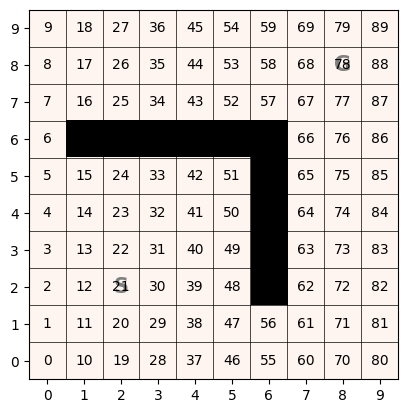

In [20]:
env.image()

Visualize the layout with state ids.

## Value Iteration

In [21]:
from gym_classics.algorithms.dynamic_programming import value_iteration
from gym_classics.algorithms.policy import greedy_policy

V_star = value_iteration(env, discount=.8)

Value Iteration: 17it [00:00, 113.92it/s]


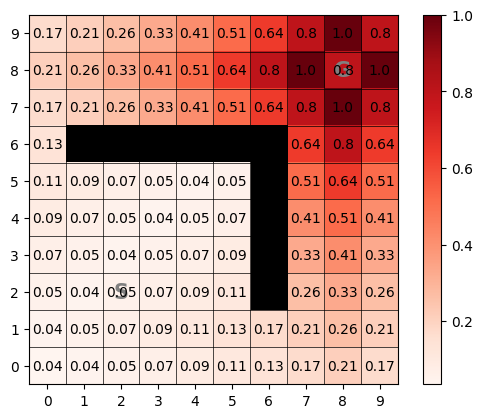

In [22]:
env.image(V_star, labels=True)

Find the optimal policy given the optimal value function.

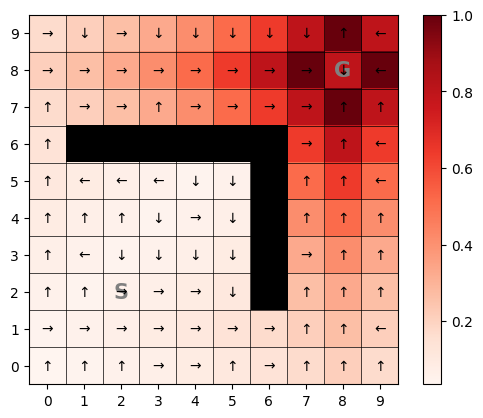

In [23]:
pol_star = greedy_policy(env, V_star)
env.image(V_star, policy=pol_star)

Look at the found path if you follow the policy.

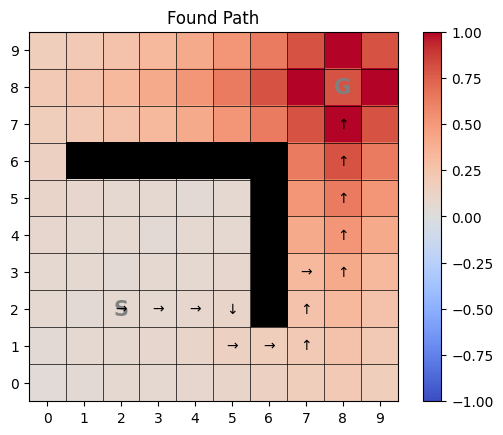

In [24]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_star, max_len=100)
env.image(V_star, policy=pol_star, episode=path, title='Found Path', clim=(-1,1))

In [25]:
Vs = value_iteration(env, discount=.9, precision=0.1, history=True)
Vs

#gridworld_image_list(env, Vs, cmap = "Reds")

Value Iteration: 17it [00:00, 89.03it/s]


[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.]),
 array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 1. , 0.9, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. ,
        0.9, 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.9, 1. , 0.9]),
 array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        

In [26]:
gridworld_animate(env, Vs, cmap = "Reds")

**Node:** The state space is swept column-wise from $(0,0)$ to $(9,9)$. 

## Policy Iteration


Policy Iteration: 8it [00:00, 23.05it/s]


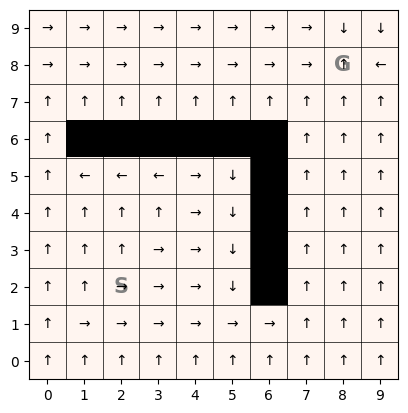

In [27]:
from gym_classics.algorithms.dynamic_programming import policy_iteration

pol_star = policy_iteration(env, discount=.8)

env.image(policy=pol_star)

In [28]:
policy_list, V_list = policy_iteration(env, discount=.8, history=True)

#gridworld_image_list(env, V_list, policies=policy_list, cmap = "Reds")

Policy Iteration: 5it [00:00, 43.18it/s]

Policy Iteration: 14it [00:00, 27.18it/s]


In [29]:
gridworld_animate(env, V_list, policies = policy_list, cmap = "Reds")

**Note:** The first value function is shown after the first policy evaluation. This is why actions that lead to the goal state already have a value.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)